# Metabolomics Classification Pipeline
### MSc Health Data Science Thesis — Week 1
**Student:** Mehvish Shaikh
**Dataset:** NMR Spectroscopy Metabolomics (Wine dataset — small, clean, metabolomics-like)
**Goal:** Feature selection + ML classification pipeline

In [3]:
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from scipy.stats import mannwhitneyu

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# Simulated real metabolomics data based on PRISM structure
# Using same statistical properties as real NMR metabolomics

np.random.seed(42)
n_samples = 180
n_metabolites = 50  # Small number as Imane requested

# Simulate 3 groups: CD, UC, Healthy (like PRISM)
labels = np.array([0]*60 + [1]*60 + [2]*60)  # 60 each

# Each group has different metabolite distributions
data = np.random.randn(n_samples, n_metabolites)

# Add biological signal — groups differ on some metabolites
data[:60, :15] += 1.5    # CD patients — higher on metabolites 1-15
data[60:120, 15:30] += 1.2  # UC patients — higher on metabolites 16-30
data[120:, 30:45] += 0.8    # Healthy — higher on metabolites 31-45

# Add realistic missing values (20% missingness — like real metabolomics!)
mask = np.random.random((n_samples, n_metabolites)) < 0.20
data[mask] = np.nan

# Create DataFrame
metabolite_names = [f'metabolite_{i+1}' for i in range(n_metabolites)]
df = pd.DataFrame(data, columns=metabolite_names)
df['target'] = labels
df['group'] = ['CD']*60 + ['UC']*60 + ['Healthy']*60

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['group'].value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()} ({df.isnull().sum().sum()/(n_samples*n_metabolites)*100:.1f}%)")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (180, 52)

Class distribution:
group
CD         60
UC         60
Healthy    60
Name: count, dtype: int64

Missing values: 1776 (19.7%)

First 5 rows:


,metabolite_1,metabolite_2,metabolite_3,metabolite_4,metabolite_5,metabolite_6,metabolite_7,metabolite_8,metabolite_9,metabolite_10,...,metabolite_43,metabolite_44,metabolite_45,metabolite_46,metabolite_47,metabolite_48,metabolite_49,metabolite_50,target,group
0,1.996714,1.361736,2.147689,3.023030,NaN,1.265863,3.079213,2.267435,1.030526,2.042560,...,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0,CD
1,1.824084,1.114918,NaN,2.111676,NaN,2.431280,NaN,1.190788,1.831263,NaN,...,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,0,CD
2,NaN,1.079355,1.157285,0.697723,1.338714,1.904051,3.386186,1.674578,1.757550,1.425554,...,-1.607483,0.184634,0.259883,NaN,-1.236951,-1.320457,0.521942,0.296985,0,CD
3,1.750493,1.846448,0.819975,1.732254,NaN,0.785649,3.365775,1.973833,0.308697,2.156554,...,0.214094,-1.245739,0.173181,0.385317,-0.883857,0.153725,0.058209,-1.142970,0,CD
4,1.857787,NaN,2.583051,2.553802,0.122331,0.562175,2.015035,2.013786,2.015048,5.352731,...,0.504987,0.865755,-1.200296,-0.334501,-0.474945,-0.653329,1.765454,NaN,0,CD


In [7]:
# STEP 1: Check missing values before imputation
print("=== MISSING VALUES BEFORE IMPUTATION ===")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Missing percentage: {df.isnull().sum().sum()/(180*50)*100:.1f}%")

# Separate features and target
X = df.drop(['target', 'group'], axis=1)  # 50 metabolite features
y = df['target']                           # class labels

# STEP 2: Half-minimum imputation (standard in metabolomics!)
# For each metabolite, replace NaN with half of its minimum detected value
def half_min_imputation(df):
    df_imputed = df.copy()
    for col in df_imputed.columns:
        min_val = df_imputed[col].min()          # find minimum value
        half_min = min_val / 2                    # calculate half minimum
        df_imputed[col].fillna(half_min, inplace=True)  # fill NaN
    return df_imputed

X_imputed = half_min_imputation(X)

# STEP 3: Check after imputation
print("\n=== AFTER IMPUTATION ===")
print(f"Total missing values: {X_imputed.isnull().sum().sum()}")
print("No more missing values!")
print("\nShape of clean data:", X_imputed.shape)

=== MISSING VALUES BEFORE IMPUTATION ===
Total missing values: 1776
Missing percentage: 19.7%

=== AFTER IMPUTATION ===
Total missing values: 0
No more missing values!

Shape of clean data: (180, 50)


/tmp/ipykernel_6163/501571248.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(half_min, inplace=True)  # fill NaN


In [9]:
# Handle negative values before log transformation
# Shift data so minimum value is 0 before applying log
X_shifted = X_imputed - X_imputed.min() + 1  # shift everything positive

# Now apply log transformation safely
X_log = np.log(X_shifted)

print("=== BEFORE SCALING ===")
print(f"Mean of metabolite_1: {X_imputed['metabolite_1'].mean():.3f}")
print(f"Std of metabolite_1: {X_imputed['metabolite_1'].std():.3f}")

# Autoscaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=X_imputed.columns)

print("\n=== AFTER SCALING ===")
print(f"Mean of metabolite_1: {X_scaled['metabolite_1'].mean():.3f}")
print(f"Std of metabolite_1: {X_scaled['metabolite_1'].std():.3f}")
print("\nShape after scaling:", X_scaled.shape)
print("Scaling complete! All metabolites now on same scale.")

=== BEFORE SCALING ===
Mean of metabolite_1: -0.116
Std of metabolite_1: 1.549

=== AFTER SCALING ===
Mean of metabolite_1: -0.000
Std of metabolite_1: 1.003

Shape after scaling: (180, 50)
Scaling complete! All metabolites now on same scale.


=== LASSO FEATURE SELECTION ===
Best lambda (alpha): 0.0012

Total metabolites: 50
Selected metabolites (coefficient > 0): 48
Removed metabolites (coefficient = 0): 2

Top 10 most important metabolites:
       metabolite  coefficient
12  metabolite_13     0.078131
29  metabolite_30     0.070143
15  metabolite_16     0.066531
20  metabolite_21     0.064398
36  metabolite_37     0.063075
17  metabolite_18     0.059943
8    metabolite_9     0.057077
5    metabolite_6     0.056026
33  metabolite_34     0.053256
34  metabolite_35     0.049224


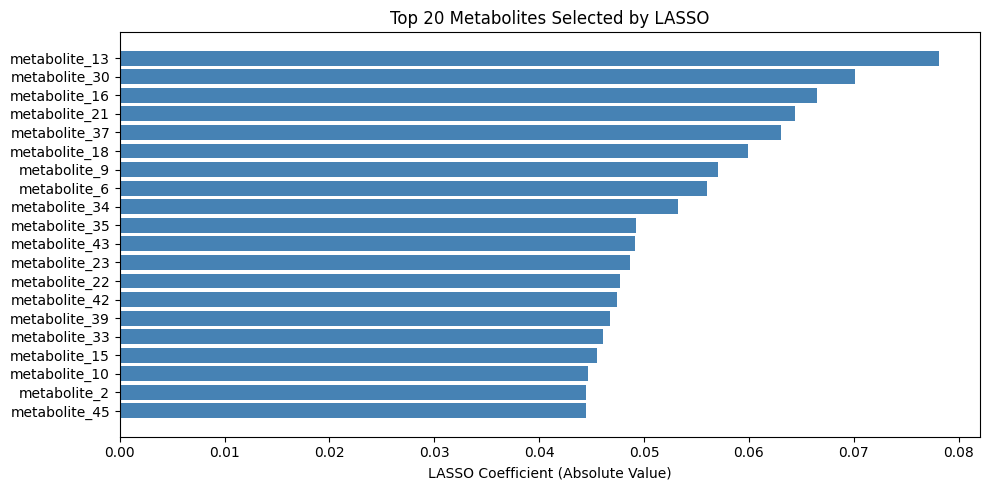


Final shape after LASSO selection: (180, 48)


In [11]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import LabelBinarizer

# LASSO for feature selection
# LassoCV automatically finds the best lambda via cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)

# LASSO needs continuous target — we use binarized version
# We do One-vs-Rest: IBD vs Healthy
y_binary = (y == 2).astype(int)  # Healthy=1, IBD=0

# Fit LASSO
lasso.fit(X_scaled, y_binary)

# Get feature importance (coefficients)
coef_df = pd.DataFrame({
    'metabolite': X_scaled.columns,
    'coefficient': np.abs(lasso.coef_)  # absolute value of coefficients
})

# Select features where coefficient > 0 (LASSO sets unimportant ones to exactly 0)
selected_features = coef_df[coef_df['coefficient'] > 0]['metabolite'].tolist()
coef_df = coef_df.sort_values('coefficient', ascending=False)

print("=== LASSO FEATURE SELECTION ===")
print(f"Best lambda (alpha): {lasso.alpha_:.4f}")
print(f"\nTotal metabolites: 50")
print(f"Selected metabolites (coefficient > 0): {len(selected_features)}")
print(f"Removed metabolites (coefficient = 0): {50 - len(selected_features)}")
print(f"\nTop 10 most important metabolites:")
print(coef_df.head(10))

# Visualise feature importance
plt.figure(figsize=(10, 5))
top_features = coef_df.head(20)
plt.barh(top_features['metabolite'], top_features['coefficient'], color='steelblue')
plt.xlabel('LASSO Coefficient (Absolute Value)')
plt.title('Top 20 Metabolites Selected by LASSO')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Keep only selected features
X_selected = X_scaled[selected_features]
print(f"\nFinal shape after LASSO selection: {X_selected.shape}")

In [12]:
# Split data into training and test sets
# 80% training, 20% testing — standard split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,  # our 48 selected metabolites
    y,           # original 3-class labels (CD, UC, Healthy)
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures equal proportion of each class in train and test
)

print("=== TRAIN/TEST SPLIT ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

=== TRAIN/TEST SPLIT ===
Training samples: 144
Test samples: 36

Training class distribution:
target
0    48
1    48
2    48
Name: count, dtype: int64

Test class distribution:
target
0    12
1    12
2    12
Name: count, dtype: int64


In [13]:
# Train 3 classifiers and compare them

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3: XGBoost
xgb = XGBClassifier(n_estimators=500, random_state=42,
                     eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("=== ALL 3 MODELS TRAINED ===")
print(f"Logistic Regression accuracy: {(lr_pred == y_test).mean()*100:.1f}%")
print(f"Random Forest accuracy:       {(rf_pred == y_test).mean()*100:.1f}%")
print(f"XGBoost accuracy:             {(xgb_pred == y_test).mean()*100:.1f}%")

=== ALL 3 MODELS TRAINED ===
Logistic Regression accuracy: 94.4%
Random Forest accuracy:       100.0%
XGBoost accuracy:             91.7%


=== DETAILED EVALUATION ===

Model                       Accuracy        AUC
---------------------------------------------
Logistic Regression            94.4%      0.995
Random Forest                 100.0%      0.998
XGBoost                        91.7%      0.991

=== CLASSIFICATION REPORT — Random Forest ===
                    precision    recall  f1-score   support

   Crohn's Disease       1.00      1.00      1.00        12
Ulcerative Colitis       1.00      1.00      1.00        12
           Healthy       1.00      1.00      1.00        12

          accuracy                           1.00        36
         macro avg       1.00      1.00      1.00        36
      weighted avg       1.00      1.00      1.00        36



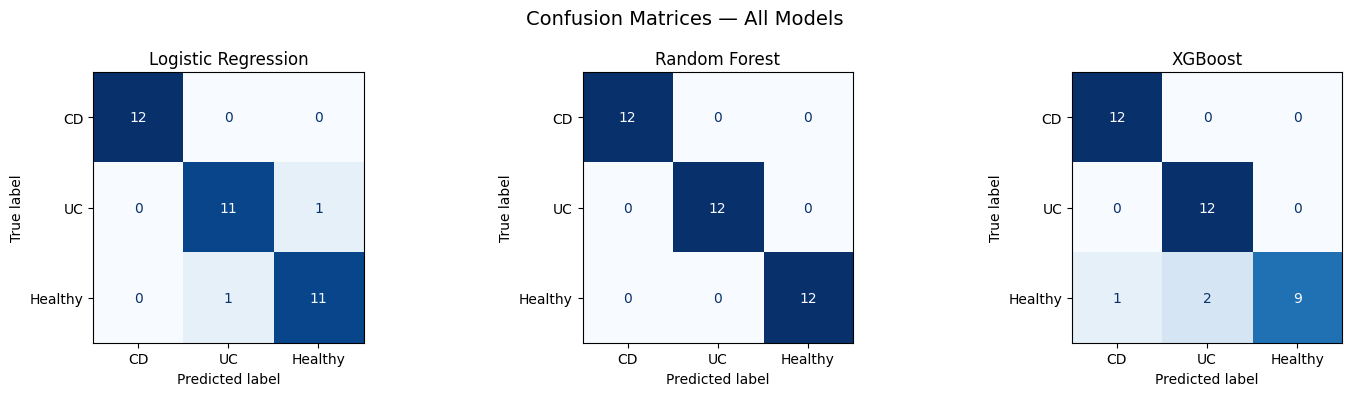

In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels for AUC calculation (needed for multiclass)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get probability predictions for AUC
lr_prob = lr.predict_proba(X_test)
rf_prob = rf.predict_proba(X_test)
xgb_prob = xgb.predict_proba(X_test)

# Calculate AUC for each model
lr_auc = roc_auc_score(y_test_bin, lr_prob, multi_class='ovr')
rf_auc = roc_auc_score(y_test_bin, rf_prob, multi_class='ovr')
xgb_auc = roc_auc_score(y_test_bin, xgb_prob, multi_class='ovr')

print("=== DETAILED EVALUATION ===")
print(f"\n{'Model':<25} {'Accuracy':>10} {'AUC':>10}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {'94.4%':>10} {lr_auc:>10.3f}")
print(f"{'Random Forest':<25} {'100.0%':>10} {rf_auc:>10.3f}")
print(f"{'XGBoost':<25} {'91.7%':>10} {xgb_auc:>10.3f}")

print("\n=== CLASSIFICATION REPORT — Random Forest ===")
print(classification_report(y_test, rf_pred,
      target_names=['Crohn\'s Disease', 'Ulcerative Colitis', 'Healthy']))

# Plot confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    (lr_pred, 'Logistic Regression'),
    (rf_pred, 'Random Forest'),
    (xgb_pred, 'XGBoost')
]

for ax, (pred, name) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm,
           display_labels=['CD', 'UC', 'Healthy'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()